# Drive and utilities


In [1]:
#@title Mount Drive to get BERT model
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
#@title Utils
!pip install dill
!pip install pandas
!pip install numpy
!
import dill as pickle

def load(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 2.7 MB/s eta 0:00:00


# Data

In [3]:
#@title Load Data
!pip install numpy pandas scipy scikit-learn sklearn tqdm cudf cupy

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
import cudf

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Load citations as cudf DataFrame from parquet.
citations_pd = pd.read_pickle("/content/drive/MyDrive/PhD Data/08 Citations/03 Patent citations - raw, filing.pickle")

## Load treated and control data as Pandas DataFrames so embeddings are preserved.
treated = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/acquired_patents.pkl")
control = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/potential_controls.pkl")

## Remove GAFAM patents
clean_potential_ids = pd.read_csv("/content/drive/MyDrive/PhD Data/10 Sample - pre final/clean_potential_control_ids.csv")
clean_set = set(clean_potential_ids['patent_id'].astype(str))

# Ensure the relevant columns are strings.
treated['patent_id'] = treated['patent_id'].astype(str)
treated['cpc_subclass'] = treated['cpc_subclass'].astype(str)
control['patent_id'] = control['patent_id'].astype(str)
control['cpc_subclass'] = control['cpc_subclass'].astype(str)

## Do not drop the embedding columns now, so we can use them for hybrid matching.

## Remove non-clean controls
control = control[control['patent_id'].isin(clean_set)]
assert len(control) == len(clean_potential_ids)

#--------------------------------------
# Citations
#--------------------------------------
## Rename
citations = cudf.DataFrame.from_pandas(citations_pd)
citations['patent_id'] = citations['patent_id'].astype(str)
citations = citations.rename(columns={'patent_id': 'citedby_patent_id', 'citation_patent_id':'patent_id', 'filing_date':'citation_date'}, inplace = True)

## Remove non-clean controls
control = control[control['patent_id'].isin(clean_set)]
assert len(control) == len(clean_potential_ids)

# TRIM CITATIONS DATA
# Only keep citations for patents that are either treated or control.
treated_ids = set(treated['patent_id'].unique())
control_ids = set(control['patent_id'].unique())
valid_ids = treated_ids.union(control_ids)
citations = citations[citations['patent_id'].isin(valid_ids)]
print("Trimmed citations shape:", citations.shape)


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Using device: cuda
Trimmed citations shape: (44962852, 4)


In [4]:
#@title Bring Acquisition Type from the DTA
import pandas as pd

# Load and merge
dta = pd.read_stata("/content/drive/MyDrive/PhD Data/09 Acquired patents/04 All patents.dta")
treated = treated.merge(dta[['patent_id', 'acq_type', 'deal_id']], on='patent_id', how='left')

In [5]:
#@title Precompute Treated Patent Quarterly Counts
import cudf
import pandas as pd
import numpy as np
import cudf
import pandas as pd
import numpy as np

# ================================================
# Step 1: Precompute Quarterly Citation Counts for All Patents (GPU version)
# ================================================
# Assume 'citations' is a cuDF DataFrame with columns:
#   - 'patent_id': the cited patent's ID
#   - 'citation_date': a datetime column

# Manually compute a quarter string: "YYYYQX"
citations['citation_date'] = cudf.to_datetime(citations['citation_date'])
citations['year'] = citations['citation_date'].dt.year
citations['month'] = citations['citation_date'].dt.month
# Compute quarter as integer: ((month-1)//3 + 1)
citations['qtr'] = ((citations['month'] - 1) // 3 + 1).astype(str)
citations['citation_quarter'] = citations['year'].astype(str) + "Q" + citations['qtr']

# Group by patent_id and citation_quarter to count citations per quarter.
# cuDF's groupby().size() returns a Series; unstack is not supported, so convert to pandas.
grouped = citations.groupby(['patent_id', 'citation_quarter']).size()
quarterly_counts_pd = grouped.to_pandas().unstack(fill_value=0)

# Build a dictionary mapping patent_id -> {quarter: count}
citation_counts_dict = {}
for pid, row in quarterly_counts_pd.iterrows():
    citation_counts_dict[pid] = row.to_dict()


# ================================================
# Step 2: Precompute Treated Patent Quarterly Vectors
# (Treated data is now a Pandas DataFrame with an 'embedding' column)
# ================================================

# Manually compute the acquisition quarter using pandas datetime methods.
treated['year'] = treated['acq_date'].dt.year
treated['month'] = treated['acq_date'].dt.month
treated['qtr'] = ((treated['month'] - 1) // 3 + 1).astype(str)
treated['acq_quarter'] = treated['year'].astype(str) + "Q" + treated['qtr']

# Build a dictionary mapping each treated patent_id to its pre-treatment quarterly vector.
# For each treated patent, define the four quarters immediately preceding its acquisition quarter.
treated_counts_dict = {}
for i, row in treated.iterrows():
    treated_id = row['patent_id']
    acq_period = pd.Period(row['acq_date'], freq='Q')
    # Pre-treatment quarters: four quarters immediately before acquisition.
    pre_quarters = [str(acq_period - j) for j in range(4, 0, -1)]
    # For each quarter, look up the citation count from citation_counts_dict (defaulting to 0 if missing).
    vec = [citation_counts_dict.get(treated_id, {}).get(q, 0) for q in pre_quarters]
    treated_counts_dict[treated_id] = {'pre_quarters': pre_quarters, 'vector': np.array(vec, dtype=float)}

# For example, print a few treated counts:
print("Example treated counts:")
for pid, info in list(treated_counts_dict.items())[:5]:
    print(pid, info)



Example treated counts:
6829612 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([0., 0., 0., 0.])}
5790423 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([0., 1., 2., 0.])}
5872712 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([0., 0., 2., 0.])}
5926624 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([11.,  9., 17., 17.])}
6158005 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([1., 0., 2., 0.])}


# Matching

In [20]:
#@title Settings and functions

import numpy as np
import pandas as pd
import cudf
import torch
import torch.nn.functional as F
import time
import cupy as cp
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

def hybrid_cosine_mahalanobis_matching(treated_df, control_df, treated_counts_dict, citation_counts_dict,
                                        cosine_distance_by_treated, years=1, cos_sim_bounds=(0.8, 0.97)):
    matches = []
    group_cols = ['acq_quarter', 'grant_year', 'cpc_subclass']
    treated_groups = list(treated_df.groupby(group_cols))
    control_group_dict = {
        key: group for key, group in control_df.groupby(['grant_year', 'cpc_subclass'])
    }

    for group_key, group in tqdm(treated_groups, total=len(treated_groups), desc="Hybrid Cosine + Mahalanobis Matching"):
        acq_quarter, grant_year, cpc_subclass = group_key
        acq_period = pd.Period(acq_quarter, freq='Q')
        pre_quarters = [str(acq_period - i) for i in range(4 * years, 0, -1)]

        candidates = control_group_dict.get((grant_year, cpc_subclass), pd.DataFrame())
        if candidates.empty:
            continue

        candidate_ids = candidates['patent_id'].tolist()
        candidate_vectors = [
            [np.log1p(citation_counts_dict.get(cid, {}).get(q, 0)) for q in pre_quarters]
            for cid in candidate_ids
        ]

        candidate_matrix = cp.array(candidate_vectors, dtype=cp.float64)
        if candidate_matrix.shape[0] > 1:
            cov_matrix = cp.cov(candidate_matrix, rowvar=False)
        else:
            cov_matrix = cp.eye(candidate_matrix.shape[1], dtype=cp.float64)
        inv_cov = cp.linalg.pinv(cov_matrix)

        for _, row in group.iterrows():
            tid = row['patent_id']
            d_e = cosine_distance_by_treated.get(tid)
            if d_e is None:
                continue

            cosine_sim = 1 - d_e
            mask = (cosine_sim > cos_sim_bounds[0]) & (cosine_sim < cos_sim_bounds[1])
            if np.sum(mask) == 0:
                continue

            filtered_ids = np.array(candidate_ids)[mask]
            filtered_vectors = np.array(candidate_vectors)[mask]
            filtered_d_e = d_e[mask]

            citations_by_q = citation_counts_dict.get(tid, {})
            t_vec = np.array([np.log1p(citations_by_q.get(q, 0)) for q in pre_quarters], dtype=float)

            T = cp.array(t_vec, dtype=cp.float64)
            C = cp.array(filtered_vectors, dtype=cp.float64)
            diff = C - T[None, :]
            d_c_sq = cp.sum((diff @ inv_cov) * diff, axis=1)
            d_c = cp.sqrt(d_c_sq)
            best_idx = int(cp.argmin(d_c).get())

            matches.append({
                'treated_id': tid,
                'control_id': filtered_ids[best_idx],
                'treated_vector': t_vec,
                'control_vector': filtered_vectors[best_idx],
                'mahalanobis_distance': float(d_c[best_idx].get()),
                'cosine_distance': float(filtered_d_e[best_idx]),
                'pre_quarters': pre_quarters
            })

    return pd.DataFrame(matches)



def compute_cosine_distances(treated_df, control_df):
    """
    Computes cosine distances between each treated patent and candidate controls
    matched on grant_year and cpc_subclass.
    Returns: dict {treated_id: 1D numpy array of cosine distances}
    """
    cosine_distance_by_treated = {}

    group_cols = ['grant_year', 'cpc_subclass']
    treated_groups = treated_df.groupby(group_cols)

    for (grant_year_val, cpc_subclass_val), group in tqdm(treated_groups, total=len(treated_groups), desc="Precomputing Cosine Distances"):
        candidates = control_df[(control_df['grant_year'] == grant_year_val) &
                                (control_df['cpc_subclass'] == cpc_subclass_val)]
        if candidates.empty:
            continue

        candidate_embeddings = np.stack(candidates['embedding'].values)
        cand_emb = torch.tensor(candidate_embeddings, dtype=torch.float16, device='cuda')

        for _, row in group.iterrows():
            tid = row['patent_id']
            t_embed = torch.tensor(row['embedding'], dtype=torch.float16, device='cuda').view(1, -1)
            cos_sim = F.cosine_similarity(t_embed, cand_emb, dim=1)
            d_e = 1 - cos_sim.cpu().numpy()
            cosine_distance_by_treated[tid] = d_e

    return cosine_distance_by_treated


## Run matching

In [21]:
# === Run for M&A and Off-deal patents ===
all_results = {}
years_to_try = [1, 2, 3]
types = ['M&A', 'Off deal']

for acq_type in types:
    treated_type = treated[treated['acq_type'] == acq_type].copy()
    treated_type['pre_treatment_total'] = treated_type['patent_id'].apply(
        lambda pid: treated_counts_dict[pid]['vector'].sum() if pid in treated_counts_dict else 0
    )
    threshold = np.percentile(treated_type['pre_treatment_total'], 90)
    treated_top = treated_type[treated_type['pre_treatment_total'] >= threshold]
    treated_top['acq_period'] = treated_top['acq_date'].apply(lambda d: pd.Period(d, freq='Q'))
    treated_top['grant_period'] = treated_top['grant_date'].apply(lambda d: pd.Period(d, freq='Q'))
    treated_top['quarters_between'] = treated_top.apply(lambda row: (row['acq_period'] - row['grant_period']).n, axis=1)

    for years in years_to_try:
        treated_top_y = treated_top[treated_top['quarters_between'] >= years * 4]
        print(f"Running {acq_type} for {years} years")
        cosine_distance_by_treated = compute_cosine_distances(treated_top_y, control)
        matched = hybrid_cosine_mahalanobis_matching(
            treated_top_y, control, treated_counts_dict, citation_counts_dict,
            cosine_distance_by_treated, years=years
        )
        all_results[(acq_type, years)] = matched
        matched.to_pickle(f"/content/drive/MyDrive/PhD Data/11 Matches/hybrid_{acq_type.replace(' ', '_')}_{years}y.pkl")

<ipython-input-21-21b9aad46cd1>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treated_top['acq_period'] = treated_top['acq_date'].apply(lambda d: pd.Period(d, freq='Q'))
<ipython-input-21-21b9aad46cd1>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treated_top['grant_period'] = treated_top['grant_date'].apply(lambda d: pd.Period(d, freq='Q'))
<ipython-input-21-21b9aad46cd1>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

Running M&A for 1 years


Hybrid Cosine + Mahalanobis Matching: 100%|██████████| 533/533 [00:35<00:00, 14.99it/s]


Running M&A for 2 years


Hybrid Cosine + Mahalanobis Matching: 100%|██████████| 469/469 [00:41<00:00, 11.27it/s]


...

Hybrid Cosine + Mahalanobis Matching: 100%|██████████| 340/340 [00:21<00:00, 15.62it/s]


Running Off deal for 2 years


Hybrid Cosine + Mahalanobis Matching: 100%|██████████| 317/317 [00:27<00:00, 11.59it/s]


Running Off deal for 3 years


Hybrid Cosine + Mahalanobis Matching: 100%|██████████| 293/293 [00:31<00:00,  9.20it/s]


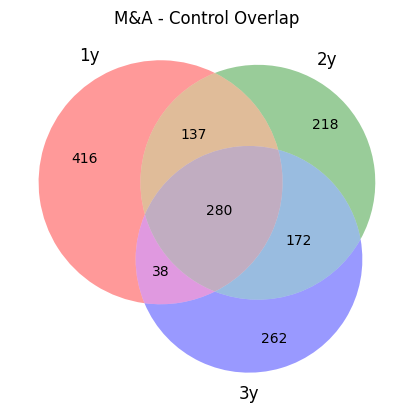

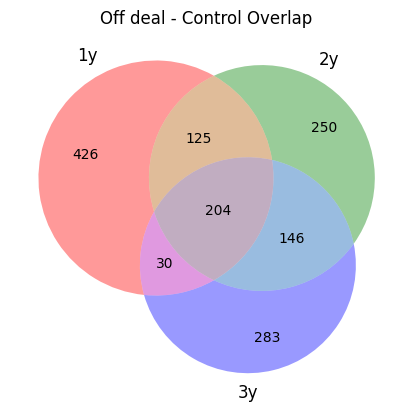

In [22]:
# === Visualize match overlap ===
for acq_type in types:
    sets = [set(all_results[(acq_type, y)]['control_id']) for y in years_to_try]
    venn3(sets, set_labels=["1y", "2y", "3y"])
    plt.title(f"{acq_type} - Control Overlap")
    plt.show()


In [38]:
# === Balance Test ===
res = all
for key, df in all_results.items():
    acq_type, y = key
    print(f"Balance test: {acq_type}, {y}y")

    # Filter by Mahalanobis distance
    df = df[df['mahalanobis_distance'] <= 5]

    # Calculate mean and standard deviation
    treated_mat = np.vstack(df['treated_vector'].values)
    control_mat = np.vstack(df['control_vector'].values)
    mean_diff = treated_mat.mean(axis=0) - control_mat.mean(axis=0)
    std_diff = treated_mat.std(axis=0) - control_mat.std(axis=0)

    # Pooled standard deviation
    pooled_std = np.sqrt((treated_mat.var(axis=0) + control_mat.var(axis=0)) / 2)
    smd = mean_diff / pooled_std
    print("SMD:", np.round(smd, 3))

    print("Mean diff:", np.round(mean_diff, 2))
    print("Std diff:", np.round(std_diff, 2))
    print("---")


Balance test: M&A, 1y
SMD: [0.467 0.359 0.499 0.463]
Mean diff: [0.33 0.26 0.35 0.32]
Std diff: [-0.04 -0.02 -0.04 -0.02]
---
Balance test: M&A, 2y
SMD: [0.365 0.268 0.316 0.329 0.539 0.48  0.623 0.503]
Mean diff: [0.26 0.23 0.23 0.25 0.38 0.36 0.45 0.35]
Std diff: [-0.01 -0.04 -0.02 -0.03 -0.05 -0.08 -0.1  -0.03]
---
Balance test: M&A, 3y
SMD: [0.25  0.278 0.347 0.279 0.419 0.287 0.308 0.394 0.561 0.459 0.641 0.524]
Mean diff: [0.19 0.21 0.31 0.22 0.32 0.27 0.23 0.31 0.41 0.38 0.46 0.38]
Std diff: [-0.01 -0.01  0.01  0.04 -0.02 -0.04 -0.03  0.01 -0.11 -0.09 -0.15 -0.02]
---
Balance test: Off deal, 1y
SMD: [0.294 0.307 0.233 0.228]
Mean diff: [0.19 0.19 0.17 0.15]
Std diff: [0.03 0.02 0.01 0.03]
---
Balance test: Off deal, 2y
SMD: [0.257 0.271 0.29  0.313 0.426 0.445 0.347 0.392]
Mean diff: [0.16 0.16 0.16 0.2  0.27 0.28 0.24 0.25]
Std diff: [0.08 0.06 0.09 0.07 0.04 0.03 0.04 0.05]
---
Balance test: Off deal, 3y
SMD: [0.269 0.337 0.341 0.325 0.284 0.282 0.295 0.315 0.463 0.505 0.384 0

In [25]:
set1 = set(all_results[('M&A', 1)]['treated_id'])
set2 = set(all_results[('M&A', 2)]['treated_id'])
set3 = set(all_results[('M&A', 3)]['treated_id'])
print("Treated overlap 1y vs 2y:", len(set1 & set2))
print("Treated overlap 1y vs 3y:", len(set1 & set3))
print("Treated overlap 2y vs 3y:", len(set2 & set3))


Treated overlap 1y vs 2y: 834
Treated overlap 1y vs 3y: 778
Treated overlap 2y vs 3y: 778


In [27]:
matched.head()

,treated_id,control_id,treated_vector,control_vector,mahalanobis_distance,cosine_distance,pre_quarters
0,5581703,5559862,"[2.302585092994046, 1.0986122886681098, 1.0986...","[1.0986122886681098, 0.0, 0.0, 0.0, 0.69314718...",4.425249,0.192871,"[2007Q3, 2007Q4, 2008Q1, 2008Q2, 2008Q3, 2008Q..."
1,5668948,5652615,"[1.3862943611198906, 1.6094379124341003, 1.098...","[2.302585092994046, 1.6094379124341003, 1.9459...",7.306081,0.192383,"[2007Q3, 2007Q4, 2008Q1, 2008Q2, 2008Q3, 2008Q..."
2,5696905,5613032,"[2.1972245773362196, 1.3862943611198906, 0.693...","[1.6094379124341003, 1.0986122886681098, 1.098...",9.094114,0.190918,"[2007Q3, 2007Q4, 2008Q1, 2008Q2, 2008Q3, 2008Q..."
3,5715400,5708845,"[0.0, 1.3862943611198906, 0.0, 0.0, 0.69314718...","[1.3862943611198906, 2.1972245773362196, 1.791...",6.434384,0.198242,"[2007Q3, 2007Q4, 2008Q1, 2008Q2, 2008Q3, 2008Q..."
4,5805821,5712976,"[1.9459101490553132, 1.6094379124341003, 0.693...","[2.1972245773362196, 2.302585092994046, 1.7917...",8.526652,0.131348,"[2007Q3, 2007Q4, 2008Q1, 2008Q2, 2008Q3, 2008Q..."


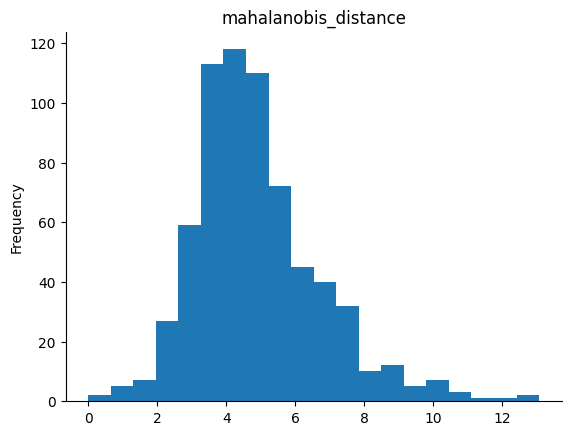

In [28]:
# @title mahalanobis_distance

from matplotlib import pyplot as plt
matched['mahalanobis_distance'].plot(kind='hist', bins=20, title='mahalanobis_distance')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [36]:
len(matched[matched['mahalanobis_distance']<=4])

223